In [1]:
import os
os.chdir("../")
configs_file = "train_cvit"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
jax.config.update("jax_default_matmul_precision", "highest")
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ice_melting.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 7,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

In [3]:
def ic_fn(a, b, theta, x, y, epsilon, Lc=None):
    # a, b, x, y, are expected to be the physical coordinates
    
    if Lc is not None:
        # indicate that x, y are normalized coordinates
        x = x * Lc
        y = y * Lc

    # a, b, theta: scalars
    x_rot = x * jnp.cos(theta) + y * jnp.sin(theta)
    y_rot = -x * jnp.sin(theta) + y * jnp.cos(theta)

    term = jnp.sqrt((x_rot / a)**2 + (y_rot / b)**2) 
    scale = 2 * a * b / (a + b)
    dist = scale * (1.0 - term)

    u = jnp.tanh(dist / (jnp.sqrt(2) * epsilon)) # shape (H, W) or scalar
    return u

In [4]:
from models import get_model

key = jax.random.PRNGKey(0)
model_params = configs.model_params
model_skeleton = get_model(
    model_name=configs.model_name,
    key=key,
    **model_params,
)

# weight = "/root/autodl-tmp/tf-logs/ice_melting/ellipse/cvit/1230_25k_norar_causal_gradclip/model_epoch_25000.eqx"
# weight = "/root/autodl-tmp/tf-logs/ice_melting/ellipse/cvit/baseline2/model_epoch_14500.eqx"
weight = "/root/autodl-tmp/tf-logs/ice_melting/ellipse/cvit/sota-0121/model_epoch_14500.eqx"
# weight = "/root/autodl-tmp/tf-logs/ice_melting/circle/1228baseline/model_epoch_25000.eqx"
model = eqx.tree_deserialise_leaves(weight, model_skeleton)

In [5]:
# data_dir = configs.data_dir
data_dir = "./data/ice_melting/ellipse_refined_dt"
# data_dir = "./data/ice_melting/circle"
target_ts = [0.0, 1.0, 2.0, 3.0]
data_dir = data_dir
Lc = configs.Lc
Tc = configs.Tc
params = jnp.load(f"{data_dir}/initial_params.npy")
solutions = jnp.load(f"{data_dir}/solutions.npy") # (B, fem_steps, C, H, W)
fem_times = jnp.load(f"{data_dir}/times.npy") # (fem_steps,)
mesh_grids = jnp.load(f"{data_dir}/mesh_points.npy") # shape: (2, H, W)
idxs = jnp.array([jnp.argmin(jnp.abs(fem_times - t)) for t in target_ts]) # shape: (T,)
ref_sols = solutions[:, idxs, :, :, :]  # (B, T, C, H, W)
B, T, C, H, W = ref_sols.shape
us = ref_sols[:, 0, :, :, :]  # (B, C=1, H, W)
# us: (B, C=1, H, W)
# params: (B, P=3) --> (a, b, theta)
# mesh_grids: (2, H, W)
# target_ts: List of time steps to evaluate
# Lc, Tc: characteristic length and time scales
B, C, H, W = us.shape
meshx = mesh_grids[0]  # (H, W)
meshy = mesh_grids[1]  # (H, W)
x_coord = jnp.stack([meshx.reshape(-1), meshy.reshape(-1)], axis=-1) / Lc  # (H*W, 2)

def fwd_fn(carry, t):
    t_coord = jnp.full(
        (x_coord.shape[0], 1), t
    ) / Tc  # (H*W, 1)
    sol = jax.vmap(
        model, in_axes=(0, None, None)
    )(us, x_coord, t_coord)  # (B, H*W, C=1)
    return carry, sol

_, solutions_pred = jax.lax.scan(
    fwd_fn,
    None,
    fem_times,
)  # sols: (T, B, H*W, C=1)
# T, B, H*W, C=1 --> B, T, C, H, W
# solutions_pred = solutions_pred.transpose(1, 0, 3, 2).reshape(B, len(fem_times), C, H, W)
solutions_pred = rearrange(solutions_pred, "t b (h w) c -> b t c h w", h=int(H), w=int(W))

sols = solutions_pred[:, idxs, :, :, :]


/tmp/ipykernel_6226/1488719370.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


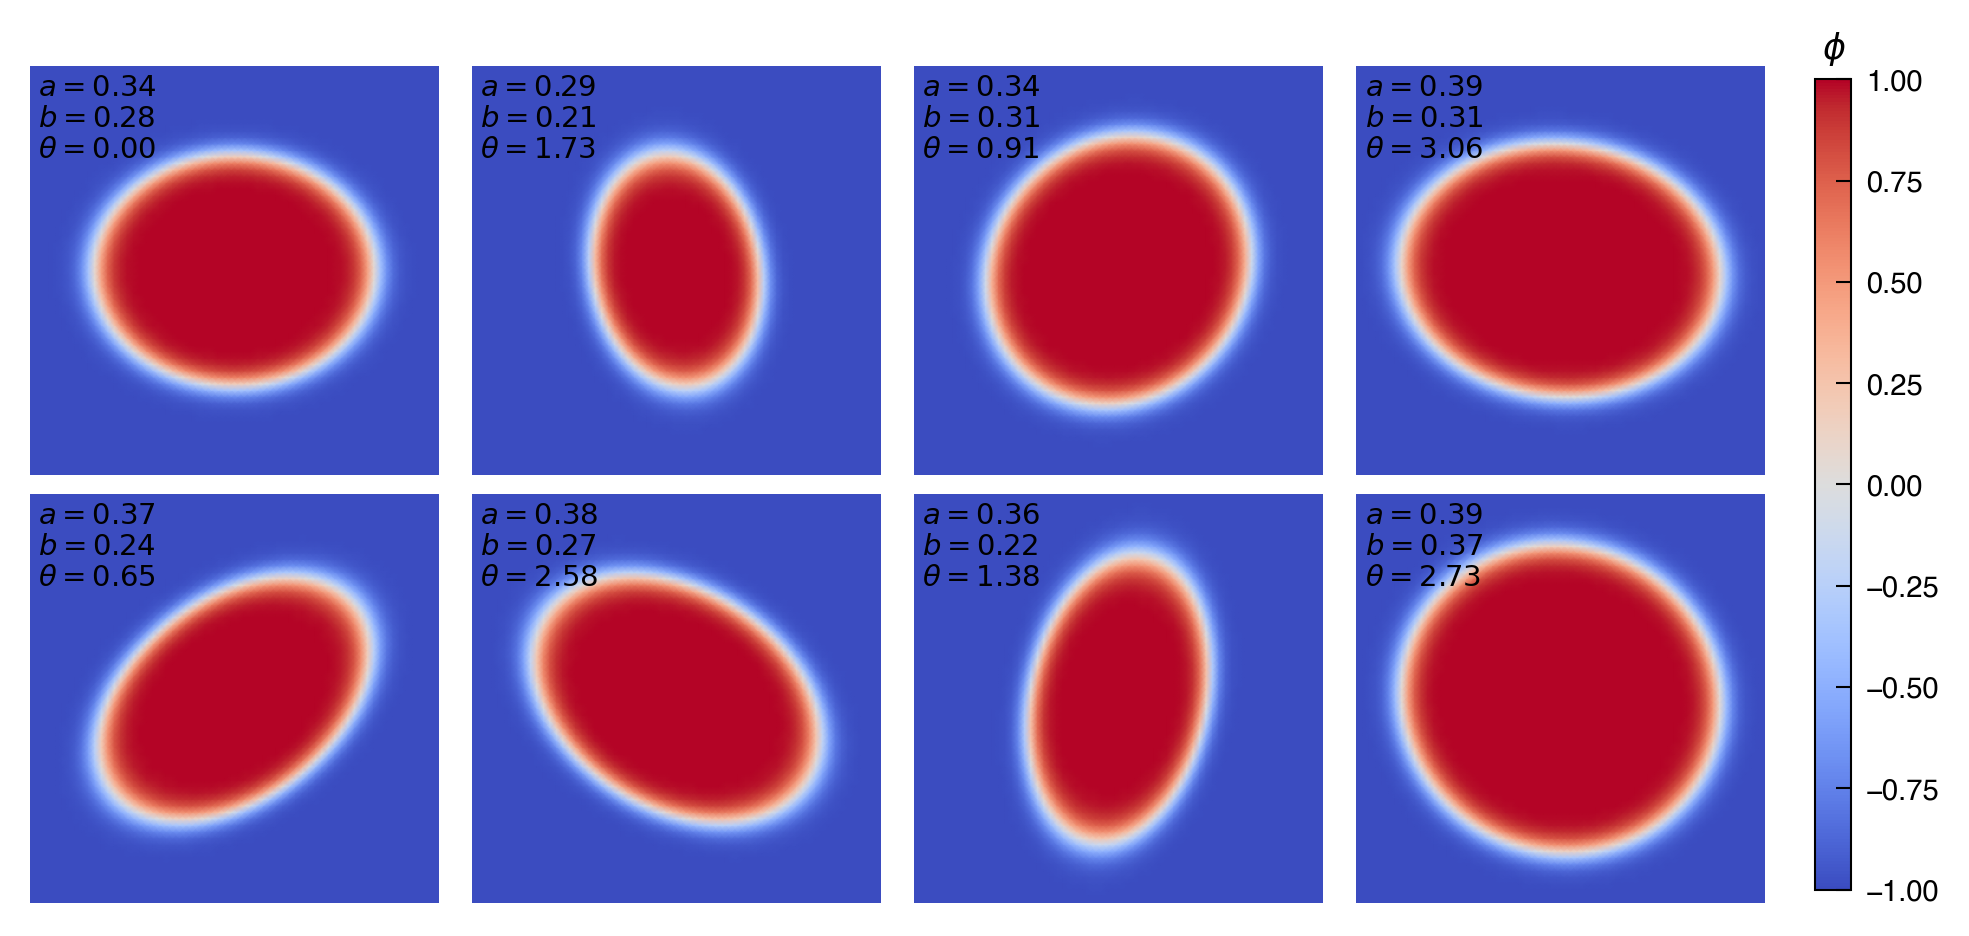

In [6]:

# test_data_overview
fig, axes = plt.subplots(2, 4, figsize=(6, 3))
axes = axes.flatten()
for b in range(B):
    ax = axes[b]
    ax.pcolormesh(
        meshx, meshy, us[b, 0, :, :], cmap="coolwarm", vmin=-1, vmax=1,
        shading="gouraud", rasterized=True
    )
    ax.set_axis_off()
    ax.set_aspect("equal")
    ax.text(0.02, 0.98, fr"$a={params[b, 0]/100:.2f}$" + "\n" + fr"$b={params[b, 1]/100:.2f}$" + "\n" + fr"$\theta={params[b, 2]:.2f}$",
            transform=ax.transAxes, ha='left', va='top')
    
vmin = -1.0
vmax = 1.0
cbar_ax = fig.add_axes([1.01, 0.05, 0.02, 0.9])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax,)
cbar_ax.set_title(r"$\phi$", pad=5)
    
fig.tight_layout()
# fig.savefig("./figures/ice_melting_test_data_overview.pdf", bbox_inches="tight", dpi=300)


Total relative L2 error: 0.016757


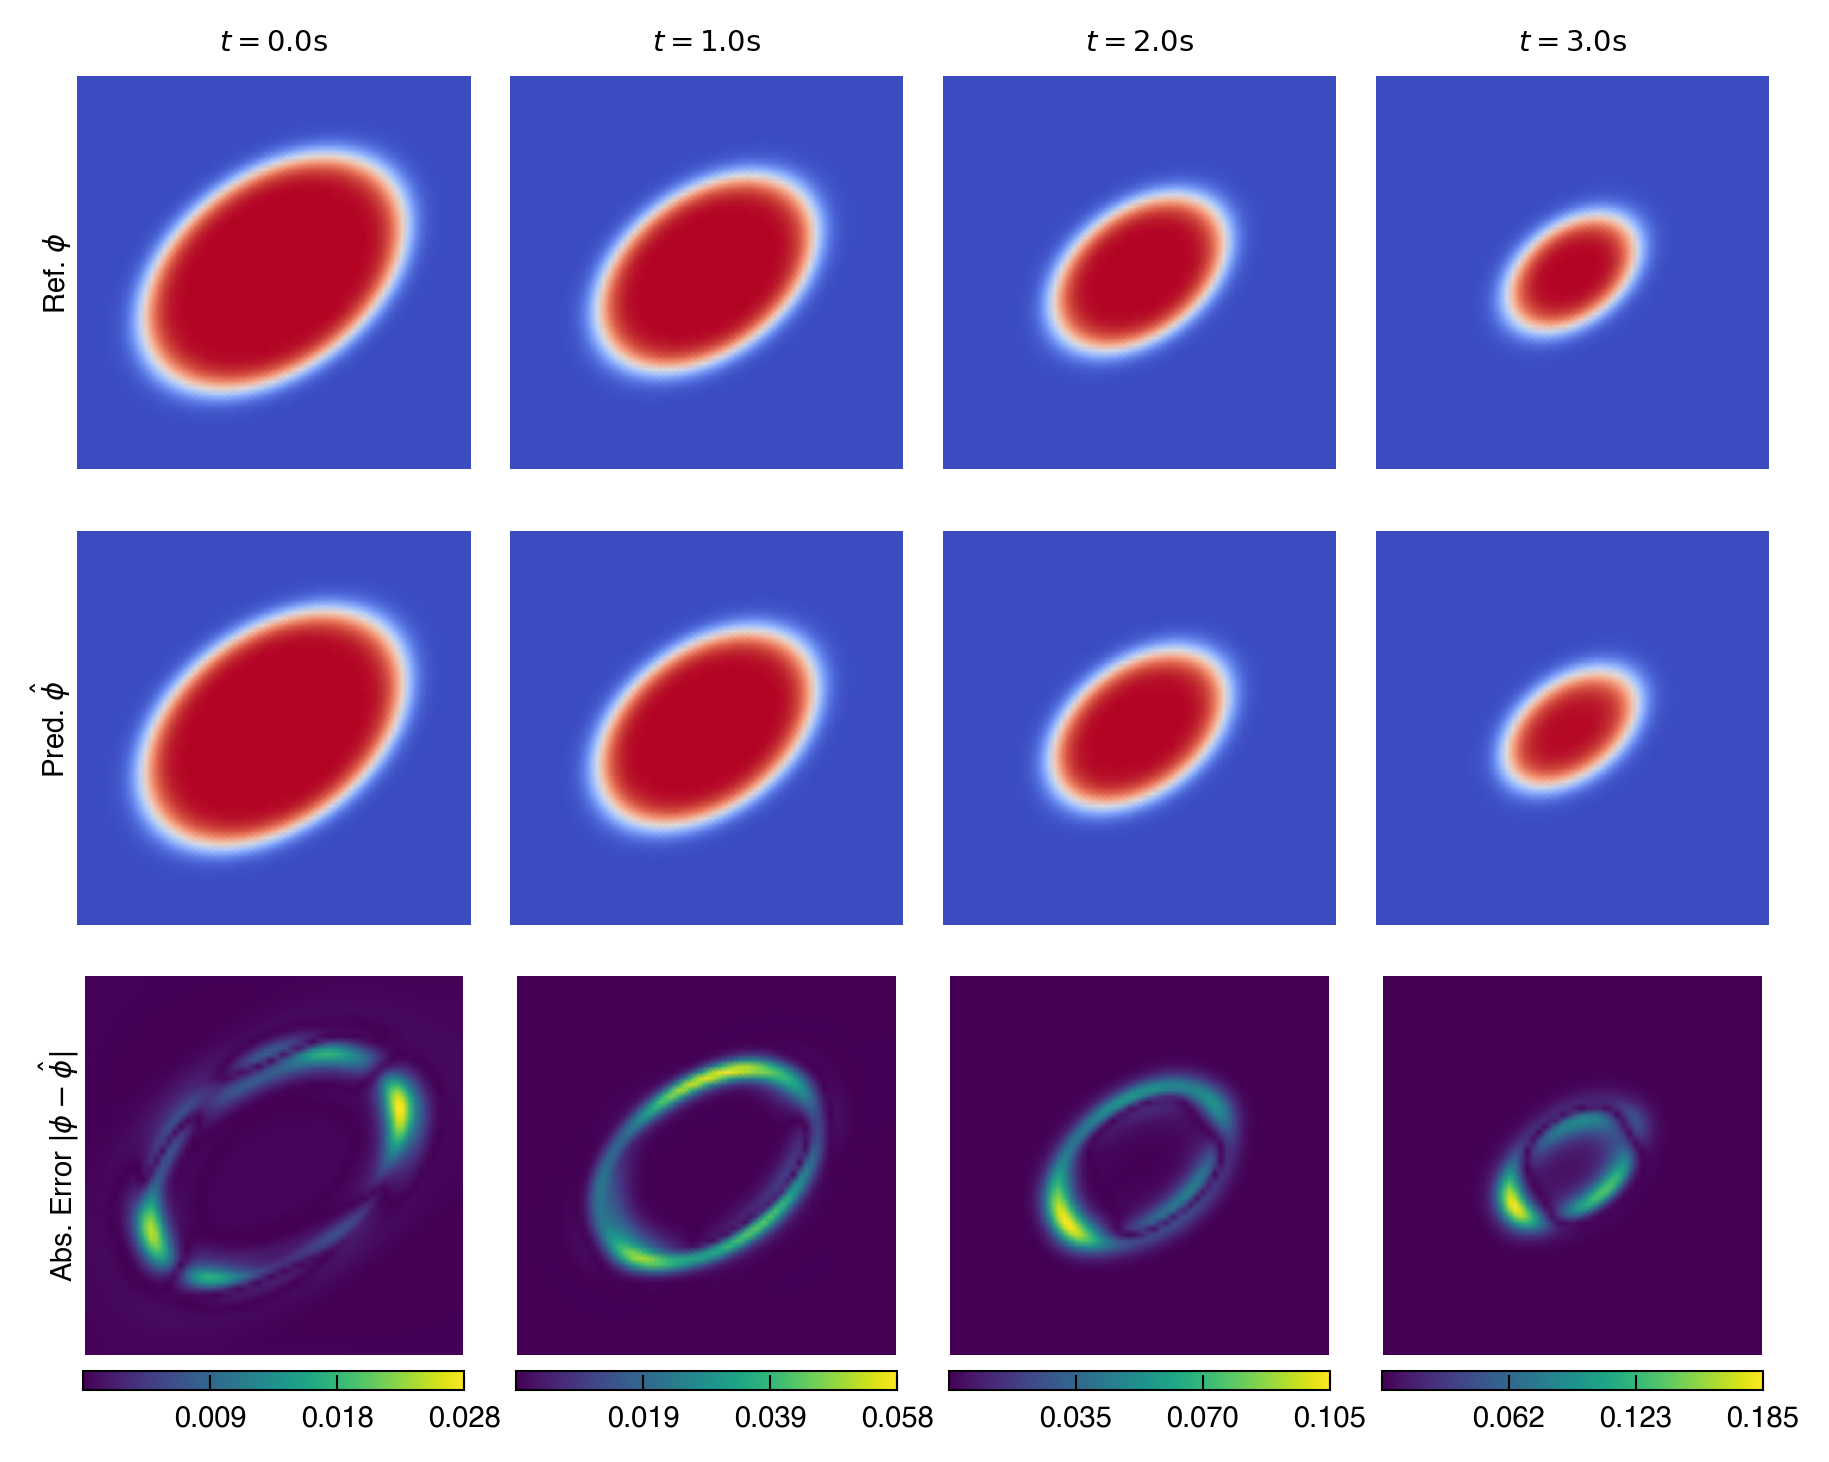

In [7]:
batch_th = 4
channel_th = 0  # only evaluate the first channel
fig, axes = plt.subplots(3, len(target_ts), figsize=(1.5 * len(target_ts), 4.8), subplot_kw={
    "aspect": "equal",
})
for i, tic in enumerate(target_ts):
    # plot reference
    ax = axes[0, i]
    ax.set_axis_off()
    ax.pcolormesh(
        meshx, meshy, 
        ref_sols[batch_th, i, channel_th, :, :], 
        cmap="coolwarm", shading="gouraud", rasterized=True,
        vmin=-1.0, vmax=1.0,
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Ref. $\phi$", 
                rotation=90, va="center", ha="right", transform=ax.transAxes
        )
    
    ax.text(0.5, 1.05, fr"$t={tic:.1f}\mathrm{{s}}$",
            va="bottom", ha="center", transform=ax.transAxes)
    
    ax = axes[1, i]
    ax.set_axis_off()
    ax.pcolormesh(
        meshx, meshy, 
        sols[batch_th, i, channel_th, :, :], 
        cmap="coolwarm", shading="gouraud", rasterized=True,
        vmin=-1.0, vmax=1.0,
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Pred. $\hat{\phi}$", 
                rotation=90, va="center", ha="right", transform=ax.transAxes
        )

    ax = axes[2, i]
    ax.set_axis_off()
    diff = jnp.abs(
        ref_sols[batch_th, i, channel_th, :, :] - sols[batch_th, i, channel_th, :, :]
    )
    diff_cont = ax.pcolormesh(
        meshx, meshy,
        diff,
        cmap="viridis", shading="gouraud", rasterized=True
    )
    if i == 0:
        ax.text(-0.01, 0.5, r"Abs. Error $|\phi - \hat{\phi}|$", 
            rotation=90, va="center", ha="right", transform=ax.transAxes
        )

    colorbar = fig.colorbar(
        diff_cont, ax=ax, fraction=0.046, pad=0.04,
        orientation="horizontal", 
        format="%.3f", ticks=jnp.linspace(0, jnp.max(diff), num=4)[1:]
    )

# total_l2 = jnp.linalg.norm(
#     ref_sols - sols, axis=(1, 3, 4)
# ) / jnp.linalg.norm(
#     ref_sols, axis=(1, 3, 4)
# )  # shape: (B, C)
total_l2 = jnp.sqrt(
    jnp.sum((ref_sols - sols) ** 2, axis=(1, 3, 4))
) / jnp.sqrt(
    jnp.sum(ref_sols ** 2, axis=(1, 3, 4))
)
total_l2 = jnp.mean(total_l2)
fig.subplots_adjust(
    left=0.03, right=0.97, top=0.95, bottom=0.03, hspace=0.1, wspace=0.1
)
print(f"Total relative L2 error: {total_l2:.6f}")
# fig.savefig("./figures/ice_melting_solution_field.png", dpi=300, bbox_inches="tight", pad_inches=0.03)
# fig.savefig("./figures/ice_melting_solution_field.pdf", dpi=300, bbox_inches="tight", pad_inches=0.03)

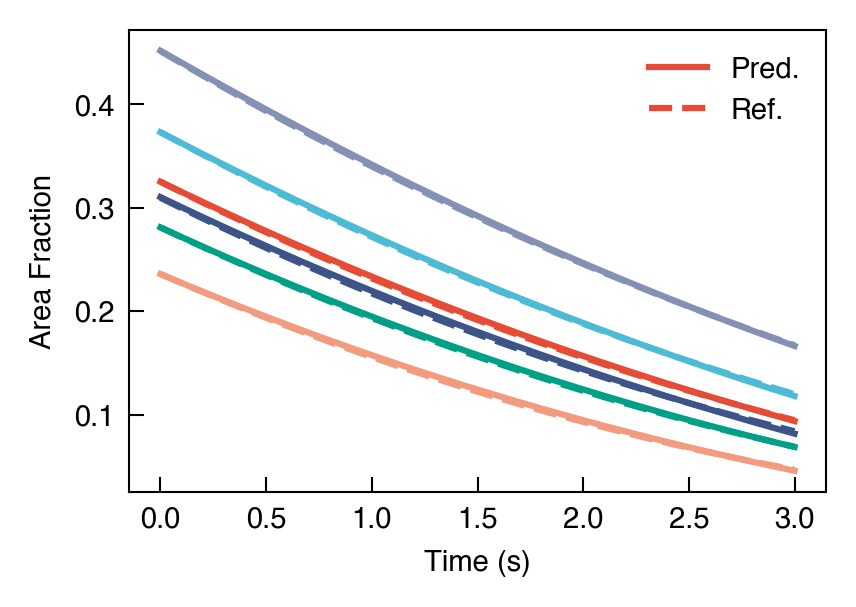

In [9]:
# area fraction

def compute_area_frac(sol):
    # sol shape: (..., H, W)
    area_frac = jnp.mean((sol + 1.0) / 2.0, axis=(-2, -1))
    return area_frac

area_fracs_ref = compute_area_frac(solutions)  # (B, T, 1)
area_fracs_pred = compute_area_frac(solutions_pred)  # (B, T, 1)
area_fracs_ref = area_fracs_ref.squeeze(-1)  # (B, T)
area_fracs_pred = area_fracs_pred.squeeze(-1)  # (B, T

fig, ax = plt.subplots(figsize=(3, 2))
for b in range(2, B):
    ax.plot(
        fem_times, area_fracs_pred[b, :], 
        color=f"C{b-2}", linestyle="-", label="Pred." if b == 2 else None
    )
    ax.plot(
        fem_times, area_fracs_ref[b, :], 
        color=f"C{b-2}", linestyle="--", label="Ref." if b == 2 else None
    )

ax.set_xlabel("Time (s)")
ax.set_ylabel("Area Fraction")
ax.legend()
# fig.savefig("./figures/ice_melting_area_fraction.png", dpi=300, bbox_inches="tight", pad_inches=0.0)
# fig.savefig("./figures/ice_melting_area_fraction.pdf", dpi=300, bbox_inches="tight", pad_inches=0.0)

In [9]:
import numpy as np
from scipy.ndimage import gaussian_filter1d


def smooth_loss_log_gaussian(
    y,
    sigma=10,
    ci=0.95,
    n_boot=200,
    eps=1e-12,
    random_state=None,
):
    """
    Smooth noisy loss curves in log-space using Gaussian filtering
    with bootstrap confidence intervals.

    Parameters
    ----------
    y : array-like
        Original loss sequence
    sigma : float
        Gaussian smoothing strength (larger = smoother)
    ci : float
        Confidence interval level
    n_boot : int
        Number of bootstrap samples
    eps : float
        Prevent log(0)
    random_state : int or None

    Returns
    -------
    mean : np.ndarray
        Smoothed curve
    lower : np.ndarray
        Lower CI
    upper : np.ndarray
        Upper CI
    """

    rng = np.random.default_rng(random_state)

    y = np.asarray(y)
    logy = np.log(y + eps)

    # ---- main smoothing ----
    smooth_log = gaussian_filter1d(logy, sigma=sigma)

    # ---- bootstrap CI ----
    boots = []

    n = len(logy)

    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        sample = logy[idx]

        # sort to maintain temporal structure
        sample = sample[np.argsort(idx)]

        sm = gaussian_filter1d(sample, sigma=sigma)
        boots.append(sm)

    boots = np.array(boots)

    alpha = 1 - ci
    lower_log = np.percentile(boots, 100 * alpha / 2, axis=0)
    upper_log = np.percentile(boots, 100 * (1 - alpha / 2), axis=0)

    mean = np.exp(smooth_log)
    lower = np.exp(lower_log)
    upper = np.exp(upper_log)

    return mean, lower, upper

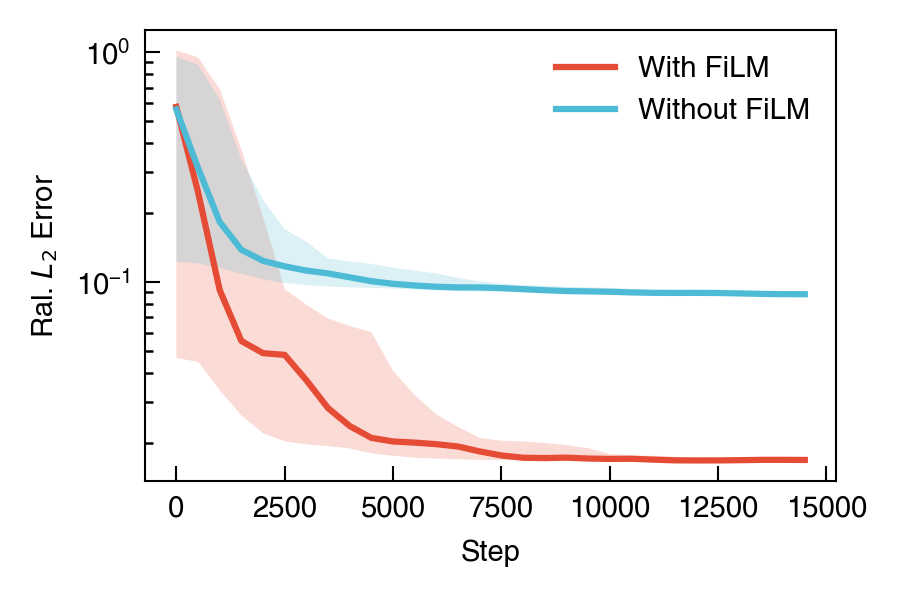

In [13]:
import pandas as pd 

paths = [
    "training_logs/ice_melting/run-ice_melting_ellipse_cvit_sota-0121-tag-eval_l2_error.csv",
    "training_logs/ice_melting/run-ice_melting_ellipse_cvit_no-film-tag-eval_l2_error.csv",
]

tags = ["With FiLM", "Without FiLM"]

final_step = 15000

fig, ax = plt.subplots(figsize=(3, 2))
for i, (path, tag) in enumerate(zip(paths, tags)):
    df = pd.read_csv(path)
    df = df[df["Step"] <= final_step]
    val = df["Value"]
    step = df["Step"]
    # ax.plot(df["Step"], df["Value"], label=tag)
    mean, lower, upper = smooth_loss_log_gaussian(val, sigma=1, n_boot=1000)
    ax.plot(step, mean, label=tag)
    ax.fill_between(step, lower, upper, alpha=0.2)
ax.set(xlabel="Step", ylabel="Ral. $L_2$ Error", yscale="log")
ax.legend()
plt.tight_layout()
plt.show()